In [5]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from nltk.corpus import stopwords
from sklearn.metrics import silhouette_score

import nltk
import sqlite3

pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

db_path = '/Users/zphilipp/git/research/dealsdb/deals_db1.db'

prepositions_and_conjunctions = [
    "about", "above", "across", "after", "against", "along", "among", "around", "at",
    "before", "behind", "below", "beneath", "beside", "between", "beyond", "by",
    "during", "for", "from", "in", "inside", "into", "near", "of", "off", "on",
    "out", "outside", "over", "through", "throughout", "to", "toward", "under",
    "until", "up", "with", "within", "without", "and", "but", "or", "for", "nor",
    "so", "yet", "although", "because", "as", "since", "unless", "while", "when",
    "where", "after", "before", "the", "a", "b", "c", "d", "e", "f", "g", "h",
    "i", "j", "k", "l", "m", "n", "o", "p", "q", "r", "s", "t", "u", "v", "w",
    "x", "y", "z"
]
pattern = r'\b(?:' + '|'.join(prepositions_and_conjunctions) + r')\b'

def remove_prepositions_and_conjunctions(text):
    cleaned_text = re.sub(pattern, '', text, flags=re.IGNORECASE)
    cleaned_text = re.sub(r'\d+', '', cleaned_text)
    return re.sub(r'\s+', ' ', cleaned_text).strip()

nltk.download('punkt')

[nltk_data] Downloading package punkt to /Users/zphilipp/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [2]:
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

sql_query = """
    SELECT d.id, c.name || ' - ' ||  GROUP_CONCAT(d.title_general) || '. '||GROUP_CONCAT (o.title) as text
    FROM deals d
        JOIN customer_category c ON c.id=d.customer_category_id
        JOIN options o ON o.deal_id=d.id
    GROUP BY d.id
"""

# Execute the query and load the data into a DataFrame
df = pd.read_sql_query(sql_query, conn)
conn.close()

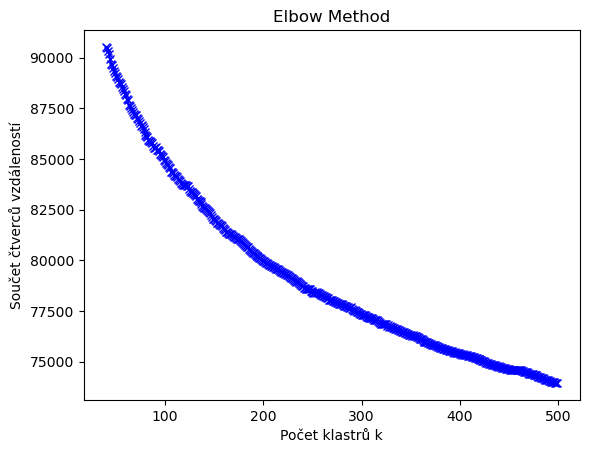

In [3]:
import matplotlib.pyplot as plt

texts = df['text'].tolist()
tfidf_vectorizer = TfidfVectorizer(stop_words=stopwords.words('english'))

# Transformace textů na TF-IDF matici
tfidf_matrix = tfidf_vectorizer.fit_transform(texts)

# Optimalizace počtu klastrů pomocí Elbow metody
sum_of_squared_distances = []
K = range(40, 500)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(tfidf_matrix)
    sum_of_squared_distances.append(km.inertia_)

# Grafik pro výběr počtu klastrů
plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('Počet klastrů k')
plt.ylabel('Součet čtverců vzdáleností')
plt.title('Elbow Method')
plt.show()

In [6]:
# Vyzkoušejte různé klastery a spočítejte Silhouette Score
silhouette_scores = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(tfidf_matrix)
    silhouette_avg = silhouette_score(tfidf_matrix, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"Počet klastrů: {k}, Silhouette Score: {silhouette_avg}")

# Nejlepší k je ten s nejvyšší hodnotou Silhouette Score
best_k = K[silhouette_scores.index(max(silhouette_scores))]
print(f'Nejlepší počet klastrů je {best_k}')

Počet klastrů: 40, Silhouette Score: 0.04945048502231824
Počet klastrů: 41, Silhouette Score: 0.0486727851386134
Počet klastrů: 42, Silhouette Score: 0.04904388304339414
Počet klastrů: 43, Silhouette Score: 0.04972613548482776
Počet klastrů: 44, Silhouette Score: 0.05035505618321126
Počet klastrů: 45, Silhouette Score: 0.051395637560850804
Počet klastrů: 46, Silhouette Score: 0.05178656916500025
Počet klastrů: 47, Silhouette Score: 0.05252266562392219
Počet klastrů: 48, Silhouette Score: 0.05222046901649505
Počet klastrů: 49, Silhouette Score: 0.05283745335772236
Počet klastrů: 50, Silhouette Score: 0.053186402049436025
Počet klastrů: 51, Silhouette Score: 0.05426583590270725
Počet klastrů: 52, Silhouette Score: 0.0541940974440631
Počet klastrů: 53, Silhouette Score: 0.05473501907588385
Počet klastrů: 54, Silhouette Score: 0.0547528228038712
Počet klastrů: 55, Silhouette Score: 0.052472405248705924
Počet klastrů: 56, Silhouette Score: 0.0528593708429601
Počet klastrů: 57, Silhouette Sc

In [52]:
df.head()

,id,text
0,1,"Barber Shop - Transform Your Look with Men's Haircut with Optional Wash and Beard Trim at 028 Barber School (Up to 64% Off),Transform Your Look with Men's Haircut with Optional Wash and Beard Trim at 028 Barber School (Up to 64% Off),Transform Your Look with Men's Haircut with Optional Wash and Beard Trim at 028 Barber School (Up to 64% Off). One Men's Haircut, Beard trim and Wash,One Men's Haircuts and Wash,One Men's Haircut"
1,2,"Things To Do - Experience Jersey Axe House with Admission for Groups of 4, 6, or 8 People and Save up to 22%,Experience Jersey Axe House with Admission for Groups of 4, 6, or 8 People and Save up to 22%. 2-Hour Axe Throwing Experience for 8 People (Ages 12 and Up),2-Hour Axe Throwing Experience for 6 People (Ages 12 and Up)"
2,3,"Junk Removal - Experience efficient junk removal with 1-800-Junk-Refund, hauling away 1/4 truck load of items, up to 56% off.. One Quarter Truck Load of Junk Removal"
3,4,Junk Removal - Clear Out Clutter With Our 1/4 Truck Load Junk Removal Service from 1-800-Junk-Refund (Up to 52% Off). 1/4 Truck Load of Junk Removal
4,5,"Bars - Explore the Country Bar Crawl with Las Vegas Tours featuring a Party Bus, Mixed Drinks, and VIP Access up to 58% off,Explore the Country Bar Crawl with Las Vegas Tours featuring a Party Bus, Mixed Drinks, and VIP Access up to 58% off,Explore the Country Bar Crawl with Las Vegas Tours featuring a Party Bus, Mixed Drinks, and VIP Access up to 58% off,Explore the Country Bar Crawl with Las Vegas Tours featuring a Party Bus, Mixed Drinks, and VIP Access up to 58% off. Admit up to EIGHT: #1 Country Bar Crawl in Vegas w/ Party Bus & Mixed Drinks,Admit FOUR: #1 Country Bar Crawl in Vegas w/ Party Bus & Mixed Drinks,Admit TWO: #1 Country Bar Crawl in Vegas w/ Party Bus & Mixed Drinks,Admit ONE: #1 Country Bar Crawl in Vegas w/ Party Bus & Mixed Drinks"


In [7]:
tfidf_vectorizer = TfidfVectorizer(stop_words=stopwords.words('english'))
tfidf_matrix = tfidf_vectorizer.fit_transform(df['text'])

number_of_clusters = 149
kmeans = KMeans(n_clusters=number_of_clusters)
kmeans.fit(tfidf_matrix)


KMeans(n_clusters=149)

In [8]:
df['cluster'] = kmeans.labels_

In [9]:
df[['text', 'cluster']].query("cluster == 0").head(30)

,text,cluster
247,"Nightlife - General or VIP Admission to Murder Mystery Drag & Dinner Show at 330 Pine ave (Up to 50% Off),General or VIP Admission to Murder Mystery Drag & Dinner Show at 330 Pine ave (Up to 50% Off). Death Drop Divas: Murder Mystery Drag & Dinner Show VIP Ticket,2 for 1 Death Drop Divasr: Murder Mystery Drag & Dinner Show General Admission",0
1379,"City & Landmark Tours - Discover the Historic Absecon Lighthouse with Tours for Four or Six, Enjoy Up to 40% Off,Discover the Historic Absecon Lighthouse with Tours for Four or Six, Enjoy Up to 40% Off. Admission For Four,Admission For Six",0
1601,"Paintball - Experience Action Star Games with $25 Off Admission, Rental & 500 Paintballs with savings up to 100%. $25 Off Admission, Rental Package and 500 Paintballs",0
2324,"Outdoor Adventures & Tours - ⭐️ Single-Day Admission for African Safari Wildlife Park in Port Clinton Ohio (Up to 49% Off)⭐️ ,⭐️ Single-Day Admission for African Safari Wildlife Park in Port Clinton Ohio (Up to 49% Off)⭐️ ,⭐️ Single-Day Admission for African Safari Wildlife Park in Port Clinton Ohio (Up to 49% Off)⭐️ ,⭐️ Single-Day Admission for African Safari Wildlife Park in Port Clinton Ohio (Up to 49% Off)⭐️ ,⭐️ Single-Day Admission for African Safari Wildlife Park in Port Clinton Ohio (Up to 49% Off)⭐️ ,⭐️ Single-Day Admission for African Safari Wildlife Park in Port Clinton Ohio (Up to 49% Off)⭐️ ,⭐️ Single-Day Admission for African Safari Wildlife Park in Port Clinton Ohio (Up to 49% Off)⭐️ ,⭐️ Single-Day Admission for African Safari Wildlife Park in Port Clinton Ohio (Up to 49% Off)⭐️ ,⭐️ Single-Day Admission for African Safari Wildlife Park in Port Clinton Ohio (Up to 49% Off)⭐️ ,⭐️ Single-Day Admission for African Safari Wildlife Park in Port Clinton Ohio (Up to 49% Off)⭐️ . Admission for 7 people Valid Any Day,Admission for 6 people Valid Any Day,Admission for 9 people Valid Any Day,Admission for 10 people Valid Any Day,Admission for 8 people Valid Any Day,Admission for 3 people Valid Any Day,Admission for One Person Valid Any Day ,Admission for 4 people Valid Any Day,Admission for 5 people Valid Any Day,Admission for 2 people Valid Any Day",0
2460,"Paintball - Indoor Play Area Admission for One, Monday-Wednesday at AGR Sports (Up to 91% Off). Admission for One; Valid Monday-Wednesday",0
2653,"Hair Extensions & Wigs - Discover the Alabama Music Hall of Fame with admission for one or two, offering a journey through music history up to 46% off,Discover the Alabama Music Hall of Fame with admission for one or two, offering a journey through music history up to 46% off. Admission for Two,Admission for One",0
2655,"Hair Extensions & Wigs - Uncover The State of Alabama Sports Hall of Fame treasures with 4 tickets, explore unique exhibits and shop savings up to 47%. Admission for four",0
2703,"Hair Extensions & Wigs - Enjoy up to 37% off admission for two or four to Albin Polasek Museum & Sculpture Garden, featuring historic home and lakeside gardens,Enjoy up to 37% off admission for two or four to Albin Polasek Museum & Sculpture Garden, featuring historic home and lakeside gardens. Admission for Two,Admission for Four",0
4145,"Hair Extensions & Wigs - Discover America on Wheels' exhibits of classic vehicles with up to 40% off admission for one, two, or four,Discover America on Wheels' exhibits of classic vehicles with up to 40% off admission for one, two, or four,Discover America on Wheels' exhibits of classic vehicles with up to 40% off admission for one, two, or four. General admission to museum for four Adults,General admission to museum for one Adults,General admission to museum for two Adults",0
4158,Hair Extensions & Wigs - Experience American Banjo Museum's banjo history and enjoy exhibits up to 50% off admission for two.. Admission for two including 10% off gift shop purchases,0


In [10]:
df[['text', 'cluster']].query("cluster == 1").head(30)

,text,cluster
393,Vehicle Emissions Testing - Up to 40% Off on Inspection Sticker/Emission Test at 415 Sf Official Star Smog Check. Smog Checks for Cars 2016 and Newer,1
647,Vehicle Emissions Testing - Up to 49% Off on Inspection Sticker/Emission Test at 7 Days a Week Smog. Smog Check for Single Car,1
742,Vehicle Emissions Testing - Get up to 10% off with A And S Auto Clinic's Hidden Discount on Maryland State Inspection Services. Maryland State Vehicle Inspection,1
815,Vehicle Emissions Testing - Get Your PA Emissions Test with a Safety Purchase Today Up to 49% Off at A&G Customs. PA Emissions Test - Must Purchase Safety,1
845,"Vehicle Emissions Testing - Up to 20% Off on Inspection Sticker/Emission Test at Van Dorn Auto Repair,Up to 20% Off on Inspection Sticker/Emission Test at Van Dorn Auto Repair. Virginia State Vehicle Emissions Inspection,Virginia State Vehicle Safety Inspection",1
1136,Vehicle Emissions Testing - Up to 90% Off of $10 Off on Smog/Emission Test at A Smog Testing. $10 Towards a Smog,1
1216,Vehicle Emissions Testing - $39 for Smog Test for One Vehicle Year 2000 and Newer at A1 Smog And Alignment ($50 Value). Smog Test for One Vehicle; Valid for Models Year 2000 and Newer,1
1217,Vehicle Emissions Testing - $39 for Smog Test for One Vehicle Year 2000 and Newer at A1 Test Only and Smog ($50 Value). Smog Test for One Vehicle Year 2000 and Newer,1
1329,"Vehicle Emissions Testing - Visit ABC Smog Test Only for a comprehensive smog check for one vehicle, 2000 and newer, with up to 13% off.. Smog Check for One Vehicle 2000 and Newer",1
1524,Vehicle Emissions Testing - $29.75 for Smog Check for One Car Year 2000 or Newer at Access Smog Check ($40 Value). Smog Check for One Car (2000 or Newer),1


In [11]:
df[['text', 'cluster']].query("cluster == 2").head(20)

,text,cluster
3270,"Mini Golf - One Round of Indoor Glow Golf for 2, 4, or 6 at Aloha Mini Glow Golf - Mall of New Hampshire (Up to 31% Off),One Round of Indoor Glow Golf for 2, 4, or 6 at Aloha Mini Glow Golf - Mall of New Hampshire (Up to 31% Off),One Round of Indoor Glow Golf for 2, 4, or 6 at Aloha Mini Glow Golf - Mall of New Hampshire (Up to 31% Off). One Round of Indoor Glow Golf for Six,One Round of Indoor Glow Golf for Two,One Round of Indoor Glow Golf for Four",2
11182,"Golf - Experience Custom Fit Clubs at Brians Golf Works with Options Worth $100, Up to 50% Off. $100 Golf Club Fitting Session",2
11343,"Golf - Enjoy a Relaxing 9-Hole Round of Golf for One, Two, or Four People at Brookland Golf Course (Up to 37% Off),Enjoy a Relaxing 9-Hole Round of Golf for One, Two, or Four People at Brookland Golf Course (Up to 37% Off),Enjoy a Relaxing 9-Hole Round of Golf for One, Two, or Four People at Brookland Golf Course (Up to 37% Off). 9-Hole Round of Golf for Two People,9-Hole Round of Golf for Four People,9-Hole Round of Golf for One Person",2
11727,"Golf - Tee Off Anytime with Up to Four Hours of Indoor Golf at Bunker Hill Golf Course (Up to 38% Off),Tee Off Anytime with Up to Four Hours of Indoor Golf at Bunker Hill Golf Course (Up to 38% Off),Tee Off Anytime with Up to Four Hours of Indoor Golf at Bunker Hill Golf Course (Up to 38% Off). Two Hours of Indoor Golf For Up to 6 People,One Hour of Indoor Golf For Up to 6 People,Four Hours of Indoor Golf For Up to 6 People",2
13881,"Golf - At Centerbrook Golf Course, experience 9 holes of golf with cart for up to 20% off,At Centerbrook Golf Course, experience 9 holes of golf with cart for up to 20% off. 9-Hole Round of Golf for Two with Cart,9-Hole Round of Golf for Four with Cart",2
14248,"Golf - 9- or 18-Round of Golf w/ Cart for 2 or 4 at Cherry Valley Golf Course(Up to 47% Off),9- or 18-Round of Golf w/ Cart for 2 or 4 at Cherry Valley Golf Course(Up to 47% Off),9- or 18-Round of Golf w/ Cart for 2 or 4 at Cherry Valley Golf Course(Up to 47% Off),9- or 18-Round of Golf w/ Cart for 2 or 4 at Cherry Valley Golf Course(Up to 47% Off). 9-Hole Round of Golf with Cart for 4 (Monday-Friday Anytime, Sat/Sun after 2),18-Hole Round of Golf w/ Cart for 2 (Monday-Friday anytime, Sat/Sun after 2pm),9- Hole Round of Golf with Cart for 2 (Monday-Friday),18-Hole Round of Golf w/ Carts for 4 (Monday-Friday Anytime)",2
14533,"Golf - Relax at Chosen Valley Golf Club with walking golf for groups and individuals, plus enjoy up to 42% off.,Relax at Chosen Valley Golf Club with walking golf for groups and individuals, plus enjoy up to 42% off.,Relax at Chosen Valley Golf Club with walking golf for groups and individuals, plus enjoy up to 42% off.. 9-Hole Round of Golf for Four,9-Hole Round of Golf for Two,9-Hole Round of Golf for One",2
17002,"Golf - Discover Golf: Five-Week Learn How to Play Golf Class for One or Two at Cypresswood Golf Club (Up to 84% Off),Discover Golf: Five-Week Learn How to Play Golf Class for One or Two at Cypresswood Golf Club (Up to 84% Off). Five-Week ""Learn To Play Golf"" Class for One,Five-Week ""Learn To Play Golf"" Class for Two",2
21418,"Golf - Up to 44% Off on Indoor Golf at Envision Golf,Up to 44% Off on Indoor Golf at Envision Golf. One hour Standard Bay Golf Rental for up to 6 people, Valid to,Two hour Standard Bay Golf Rental for up to 6 people, Valid to",2
23973,"Mini Golf - Round of Mini Golf for One, Two or Four at Flyteco Tower Mini Golf(Up to 45% Off),Round of Mini Golf for One, Two or Four at Flyteco Tower Mini Golf(Up to 45% Off),Round of Mini Golf for One, Two or Four at Flyteco Tower Mini Golf(Up to 45% Off). Round of Mini Golf for 2,Round of Mini Golf for 1,Round of Mini Golf for 4",2


In [12]:
df[['text', 'cluster']].query("cluster == 3").head(20)

,text,cluster
91,"Swedish Massage - Up to 55% Off on Swedish Massage at 168 Spa Massage,Up to 55% Off on Swedish Massage at 168 Spa Massage,Up to 55% Off on Swedish Massage at 168 Spa Massage. 50-Minutes Pampering Foot Reflexology with Sea Salt Soak,40-Minutes Custom Chair Massage include Relax Head, Neck, Shoulder, and Back,50-Minutes Oriental Body Massage with Hot Stone Treatment",3
141,"Swedish Massage - Experience ultimate relaxation at 22 Spa Health Land with a Swedish massage or mini facial session, up to 57% off,Experience ultimate relaxation at 22 Spa Health Land with a Swedish massage or mini facial session, up to 57% off. One 30-Minute Custom Mini Facial,One 60-Minute Swedish or Relaxing Massage",3
145,"Swedish Massage - Experience relaxation at 224 Massage Palatine with a 60min Swedish massage, including hot stone and oil, up to 0%. One 60-Minute Swedish Massage with Hot Stone & Oil",3
258,"Massage - Experience relaxation at 360 Massage with Swedish massage, foot pampering and cupping up to 48% off,Experience relaxation at 360 Massage with Swedish massage, foot pampering and cupping up to 48% off,Experience relaxation at 360 Massage with Swedish massage, foot pampering and cupping up to 48% off,Experience relaxation at 360 Massage with Swedish massage, foot pampering and cupping up to 48% off. 60 minute Swedish with hot stones ,Cupping session,Face cupping, stretching and hot stone massage.,45 Minute Massage & 10min foot massage with hot towels.",3
579,"Swedish Massage - Up to 38% Off on Swedish Massage at 5 Stars Beauty Spa,Up to 38% Off on Swedish Massage at 5 Stars Beauty Spa. One 60-Minute Full-Body Swedish or Deep-Tissue Couples Massage with Hot Stone and Serum Mask,One 60-Minute Full-Body Swedish or Deep-Tissue Massage with Hot Stone",3
615,Swedish Massage - Up to 44% Off on Swedish Massage at 5R facial & massage. One 60-Minute Swedish Massage with Oil and Hot Stones,3
700,"Swedish Massage - Up to 55% Off on Swedish Massage at 912 Studio LLC,Up to 55% Off on Swedish Massage at 912 Studio LLC. One 60-Minutes Swedish Massage and 60 Minutes Deep Pore Detox Facial,One 60-Minute Swedish Body Massage with Aromatherapy or Hot stone",3
752,"Swedish Massage - Enjoy a Balanced Life Massage experience with various massage options up to 41% off,Enjoy a Balanced Life Massage experience with various massage options up to 41% off,Enjoy a Balanced Life Massage experience with various massage options up to 41% off,Enjoy a Balanced Life Massage experience with various massage options up to 41% off. 90 minute deep tissue massage with hot towels and aromatherapy,90 minute swedish massage with hot towels and aromatherapy,90 minute swedish massage with hot towels and aromatherapy,60 minute swedish massage with hot towels and aromatherapy",3
842,Custom Massage - Enjoy up to 40% off at A Kneaded Massage with a relaxing 60-minute custom or Swedish massage experience. One 60-Minute Custom or Swedish Massage,3
1093,"Swedish Massage - 60-, or 90-Minute Swedish, Hot Stone, Scalp Massage, CBD Oil with Up to 30% Off,60-, or 90-Minute Swedish, Hot Stone, Scalp Massage, CBD Oil with Up to 30% Off,60-, or 90-Minute Swedish, Hot Stone, Scalp Massage, CBD Oil with Up to 30% Off,60-, or 90-Minute Swedish, Hot Stone, Scalp Massage, CBD Oil with Up to 30% Off. 60 Minute Swedish Massage w/ Scalp Massage and Oil of Choice,90 Min Hot Stone Massage,60 Minute Hot Stone Massage,90 Min Swedish Massage w/ CBD Oil",3


In [13]:
df[['text', 'cluster']].query("cluster == 43").head(20)

,text,cluster
26939,Hair Extensions & Wigs - 1743 Delina Exclusif By Parfums De Marly Eau De Parfum Parfum Natural Spray New. 1743 Delina Exclusif By Parfums De Marly Eau De Parfum Parfum Natural Spray New Women Spray Other Scent Eau de Parfum,43
27269,Hair Extensions & Wigs - 2 Men by New Brand for Men - 3.3 oz EDT Spray. 2 Men by New Brand for Men - 3.3 oz EDT Spray Men Spray Woody 3.3 oz Eau de Toilette,43
27613,Hair Extensions & Wigs - 212 NYC by Carolina Herrera 3.4 oz EDT Spray For Men. 212 NYC by Carolina Herrera 3.4 oz EDT Spray For Men Men 3.4 Woody Spray Eau de Toilette,43
27614,Hair Extensions & Wigs - 212 Sexy 3.4oz EDT Men. 212 Sexy 3.4oz EDT Men Men Spicy Spray Eau de Toilette Please enter text value here.,43
27616,Hair Extensions & Wigs - 212 Vip 3.4oz EDT Men. 212 Vip 3.4oz EDT Men Men Fresh Spray Eau de Toilette Please enter text value here.,43
28151,Hair Extensions & Wigs - 360 by Perry Ellis 6.8 oz Eau De Toilette Spray NEW in Box for Men. 360 by Perry Ellis 6.8 oz Eau De Toilette Spray NEW in Box for Men Men Spray Other Scent Eau de Toilette,43
28847,Hair Extensions & Wigs - 717 Sexy Women Fragrance for Women Eau De Parfum Natural Spray. 717 Sexy Women Fragrance for Women Eau De Parfum Natural Spray Spray Sweet Women 3.4 FL OZ Eau de Parfum,43
29105,Hair Extensions & Wigs - ABERCROMBIE & FITCH FIERCE by Abercrombie & Fitch 3.4 OZ EAU DE COLOGNE SPRAY. ABERCROMBIE & FITCH FIERCE by Abercrombie & Fitch 3.4 OZ EAU DE COLOGNE SPRAY Men Woody Spray Eau de Cologne,43
29107,Hair Extensions & Wigs - Abercrombie & Fitch First Instinct 3.4 OZ 100 ML EDT For Men . Abercrombie & Fitch First Instinct 3.4 OZ 100 ML EDT For Men Men Spray Other Scent 3.4 OZ 100 ML Eau de Toilette,43
29134,Hair Extensions & Wigs - Giorgio Armani Acqua Di Gio Eau de Toilette Spray for Men 3.4 Fl. Oz.. Giorgio Armani Acqua Di Gio Eau de Toilette Spray for Men 3.4 Fl. Oz. Men Spray Citrus 3.4 Fl. Oz. Eau de Toilette,43


In [14]:
df[['text', 'cluster']].query("cluster == 44").head(20)

,text,cluster
640,"Dentist - Experience a Complete Dental Exam at 3rd Avenue Complete Family Dental, including Cleaning and X-Rays, up to 48% off,Experience a Complete Dental Exam at 3rd Avenue Complete Family Dental, including Cleaning and X-Rays, up to 48% off. One Exam, dental Cleaning and set of X-Rays,One Dental Exam, Cleaning, laser and set of X-Rays",44
1545,"Dental Implants - Explore dental exam, X-rays, and cleaning options at Accucare Dental with credits for crowns or dentures up to 46%,Explore dental exam, X-rays, and cleaning options at Accucare Dental with credits for crowns or dentures up to 46%,Explore dental exam, X-rays, and cleaning options at Accucare Dental with credits for crowns or dentures up to 46%. Dental Exam, X-Ray, and Cleaning with $200 Toward Crown,Dental Exam, X-Ray, and Cleaning with $300 Toward Implant Crown,Dental Exam, X-Ray, and Cleaning with $200 Toward Dentures",44
1556,"Dentist - Get a Complete Dental Exam With X-Rays and Wisdom Tooth Removal Options at Ace Dental Care (Up to 72% Off),Get a Complete Dental Exam With X-Rays and Wisdom Tooth Removal Options at Ace Dental Care (Up to 72% Off). For Dental Exam With Full Mouth X-Rays, Treatment Plan,For Wisdom Tooth Removal",44
1809,"Teeth Whitening - At Advance Dental, experience Teeth Whitening and a Dental Exam with X-Rays up to 83% off. Dental Exam and Cleaning with Bitewing X-Rays",44
1811,"Dentist - Experience a dental exam, x-rays & cleaning at Advance Dental Studio with up to 79% off for a sparkling smile. Dental Exam, x-rays, and regular cleaning",44
2804,"Teeth Cleaning - Explore Align Dental Care's Comprehensive Veneers, Implants, and More with up to 90% off,Explore Align Dental Care's Comprehensive Veneers, Implants, and More with up to 90% off,Explore Align Dental Care's Comprehensive Veneers, Implants, and More with up to 90% off,Explore Align Dental Care's Comprehensive Veneers, Implants, and More with up to 90% off,Explore Align Dental Care's Comprehensive Veneers, Implants, and More with up to 90% off,Explore Align Dental Care's Comprehensive Veneers, Implants, and More with up to 90% off. Deep Cleaning,Examination, X-Ray, Cleaning,Dental Implant Fixture Only,Bone Graft,Laminate Veneer,Teeth Whitening",44
3199,"Dental Implants - Up to 33% Off on Dental Implant / Corona / Veneer at Allure,Up to 33% Off on Dental Implant / Corona / Veneer at Allure. One Clear Swarvoski Tooth Gem with Application,Swarvoski Tooth Gem Application Only",44
3317,"Dentist - Get a comprehensive dental exam, x-rays, and basic cleaning with Alpha Dental Group for up to 88% off. One dental exam, x-rays, and basic cleaning",44
3363,"Dental Implants - Comprehensive Dental Exam, Regular Cleaning, and Full Set of X-Rays at Altitude Dental (Up to 78% Off). Comprehensive Dental Exam, Regular Cleaning and full set of X-rays",44
4119,"Teeth Cleaning - Up to 80% Off on Teeth Cleaning at AMC Dental,Up to 80% Off on Teeth Cleaning at AMC Dental. Cleaning, Exam, and X-rays,Dental Exam & X-rays",44


In [15]:
df[['text', 'cluster']].query("cluster == 51").head(20)

,text,cluster
316,"Kids Activities - Join the 3Quest Challenge for an interactive scavenger hunt in any city, with groups of up to six, and enjoy up to 40% off,Join the 3Quest Challenge for an interactive scavenger hunt in any city, with groups of up to six, and enjoy up to 40% off,Join the 3Quest Challenge for an interactive scavenger hunt in any city, with groups of up to six, and enjoy up to 40% off,Join the 3Quest Challenge for an interactive scavenger hunt in any city, with groups of up to six, and enjoy up to 40% off. 3Quest Challenge for One Person,3Quest Challenge for Two People,3Quest Challenge for Six People,3Quest Challenge for Four People",51
3518,"Kids Activities - Dive into Amazing Life's Scavenger Hunt Adventure with up to 5 People and enjoy up to 50% off this thrilling experience,Dive into Amazing Life's Scavenger Hunt Adventure with up to 5 People and enjoy up to 50% off this thrilling experience. Scavenger Hunt Adventure for Two Teams of Up to Five People per Team,Scavenger Hunt Adventure for One Team of Up to Five People",51
9137,"City & Landmark Tours - Up to 60% Off on Adventure Hunt at ScavengerHunt.com,Up to 60% Off on Adventure Hunt at ScavengerHunt.com,Up to 60% Off on Adventure Hunt at ScavengerHunt.com. Self-Guided Tuskegee‘s Tantalizing Treasure Trek Adventure Hunt for Four,Self-Guided Tuskegee‘s Tantalizing Treasure Trek Adventure Hunt for Six,Self-Guided Tuskegee‘s Tantalizing Treasure Trek Adventure Hunt for Two",51
9196,"Kids Activities - Join ScavengerHunt.com for an epic Chattanooga adventure scavenger hunt for groups of two, four, or six with up to 55% off,Join ScavengerHunt.com for an epic Chattanooga adventure scavenger hunt for groups of two, four, or six with up to 55% off,Join ScavengerHunt.com for an epic Chattanooga adventure scavenger hunt for groups of two, four, or six with up to 55% off. Chattanooga Scavenger Hunt for Six,Chattanooga Scavenger Hunt for Four,Chattanooga Scavenger Hunt for Two",51
9198,"Kids Activities - Experience ScavengerHunt.com's engaging scavenger hunts for groups of 2 to 6, with flexible timing and up to 52% off,Experience ScavengerHunt.com's engaging scavenger hunts for groups of 2 to 6, with flexible timing and up to 52% off,Experience ScavengerHunt.com's engaging scavenger hunts for groups of 2 to 6, with flexible timing and up to 52% off. Self-Guided Scavenger Hunt for Two People,Self-Guided Scavenger Hunt for Six People,Self-Guided Scavenger Hunt for Four People",51
9200,"Kids Activities - Discover thrilling scavenger hunts for groups at ScavengerHunt.com with adventures for 2, 4, or 6 people and up to 52% off,Discover thrilling scavenger hunts for groups at ScavengerHunt.com with adventures for 2, 4, or 6 people and up to 52% off,Discover thrilling scavenger hunts for groups at ScavengerHunt.com with adventures for 2, 4, or 6 people and up to 52% off. Self-Guided Scavenger Hunt for Two People,Self-Guided Scavenger Hunt for Four People,Self-Guided Scavenger Hunt for Six People",51
9203,"Kids Activities - Join ScavengerHunt.com for a self-guided scavenger hunt in Portland for up to 6 people with up to 52% off,Join ScavengerHunt.com for a self-guided scavenger hunt in Portland for up to 6 people with up to 52% off,Join ScavengerHunt.com for a self-guided scavenger hunt in Portland for up to 6 people with up to 52% off. Self-Guided Scavenger Hunt for Six People,Self-Guided Scavenger Hunt for Four People,Self-Guided Scavenger Hunt for Two People",51
9204,"Kids Activities - Embark on Tacoma's Adventure with ScavengerHunt.com for Groups of 2, 4, or 6 with up to 55% off,Embark on Tacoma's Adventure with ScavengerHunt.com for Groups of 2, 4, or 6 with up to 55% off,Embark on Tacoma's Adventure with ScavengerHunt.com for Groups of 2, 4, or 6 with up to 55% off. Self-Guided Scavenger Hunt for Four People,Self-Guided Scavenger Hunt for Six People,Self-Guided Scavenger Hunt for Two People",51
9206,"Kids Activities - Embark on a thrilling scavenger hunt with Scavenger

In [16]:
df[['text', 'cluster']].query("cluster == 52").head(20)

,text,cluster
57,Martial Arts - Begin Your Martial Arts Journey: 10 days of jiu jitsu - Up to 91% Off . 10 days of jiu jitsu for $10,52
59,"Martial Arts - Join 10th Planet Jiu Jitsu Riverside for Unlimited Martial Arts Classes, Including Jiu-Jitsu, MMA, and More with Up to 50% Off,Join 10th Planet Jiu Jitsu Riverside for Unlimited Martial Arts Classes, Including Jiu-Jitsu, MMA, and More with Up to 50% Off. One-Month Membership with Unlimited Muay Thai Classes for One Adult,One-Month Membership with Unlimited Muay Thai Classes for Two Adults",52
129,"Martial Arts - Dive into Mixed Martial Arts Classes at 2020 Martial Arts for up to 50% off. Choose between two weeks or a month of training.,Dive into Mixed Martial Arts Classes at 2020 Martial Arts for up to 50% off. Choose between two weeks or a month of training.. One Month of Mixed Martial Arts Classes,Two Weeks of Mixed Martial Arts Classes",52
267,"Martial Arts - Experience 360 Taekwondo: Martial Arts & Fitness with 10 classes and a free T-shirt, offering up to 82% off.,Experience 360 Taekwondo: Martial Arts & Fitness with 10 classes and a free T-shirt, offering up to 82% off.. 10 Taekwondo Classes with Free T-shirt,5 Taekwondo Classes",52
1225,Martial Arts - Experience Four Weeks of Unlimited Martial Arts Classes at AA Kenpo Karate with up to 69% Off for Personal Growth. Four Weeks of Unlimited Martial Arts Classes,52
1486,"Martial Arts - Unlock One or Two Month of Top-Tier Martial Arts Class at Academy of Martial Arts (Up to 50% Off),Unlock One or Two Month of Top-Tier Martial Arts Class at Academy of Martial Arts (Up to 50% Off). One Month of Martial Arts Classes,Two Months of Martial Arts Classes",52
1487,"Martial Arts - Empower Your Child with Martial Arts: 1 or 2 Month Classes at Academy of Martial Arts (Up to 55% Off),Empower Your Child with Martial Arts: 1 or 2 Month Classes at Academy of Martial Arts (Up to 55% Off). Two Months of Kids Martial Arts Classes,One Month of Kids Martial Arts Classes",52
1713,"Martial Arts - One Month of Karate Classes for One or Two Children at Adel's Martial Arts Academy Center (Up to 74% Off),One Month of Karate Classes for One or Two Children at Adel's Martial Arts Academy Center (Up to 74% Off). 1 Month of Unlimited Karate Classes for Two Children Aged 3 and Up,1 Month of Unlimited Karate Classes for One Child Aged 3 and Up",52
2009,Martial Arts - Unlock Your Potential with Advantage Martial Arts: 1 Month Unlimited for Adults or Children up to 44% Off. 1 Month Unlimited w/ Uniform for Children,52
2488,"Martial Arts - Experience Aikido Florida Aikikai's Unlimited Introductory Month with a Free Uniform, up to 55% Off. Introductory Month of Unlimited Aikido Classes + Uniform",52


In [17]:
df[['text', 'cluster']].query("cluster == 54").head(20)

,text,cluster
60,"Permanent Makeup - Transform your look: Microblading, Nano Brows, and more! at 11 - 11 Beauty Studio(Up to 55% Off),Transform your look: Microblading, Nano Brows, and more! at 11 - 11 Beauty Studio(Up to 55% Off),Transform your look: Microblading, Nano Brows, and more! at 11 - 11 Beauty Studio(Up to 55% Off),Transform your look: Microblading, Nano Brows, and more! at 11 - 11 Beauty Studio(Up to 55% Off). One Nano Brows Session with Shading ',One Nano Brows Session,One Microblading or Powder Brows Session,One Microblading and Powder Combo Session",54
186,"Permanent Makeup - Experience up to 44% off at 247 Natural Wellness Center with diverse microblading options for perfect brows,Experience up to 44% off at 247 Natural Wellness Center with diverse microblading options for perfect brows,Experience up to 44% off at 247 Natural Wellness Center with diverse microblading options for perfect brows,Experience up to 44% off at 247 Natural Wellness Center with diverse microblading options for perfect brows. One Session 3D,4D,5D...up to 9D Microblading For Two Eyebrows New Customer Only,One Eyebrow 3D,4D,5D...up to 9D Microblading For Two Eyebrows for Returning Customers,One Session 3D,4D,5D...up to 9D Microblading with Ombre For Two Eyebrows New Customer Only,One Session 3D,4D,5D...up to 9D Microblading with Ombre For Two Eyebrows for Returning Clients",54
289,"Permanent Makeup - Up to 43% Off on Microblading at 3D Brows Architect,Up to 43% Off on Microblading at 3D Brows Architect,Up to 43% Off on Microblading at 3D Brows Architect. One Microshading Session,Microblading for two people,One Microblading Session",54
290,Permanent Makeup - 3D Brows Architect offers microblading consultations with expert insights and up to 50% discount on eyebrow transformation. One Microblading Consultation,54
294,"Permanent Makeup - Achieve Fuller Brows at 3D Lash And Brow with Microblading Sessions Up to 50% Off,Achieve Fuller Brows at 3D Lash And Brow with Microblading Sessions Up to 50% Off. Microblading Session,Microblading Session with Touch-Up",54
332,"Permanent Makeup - Discover 4Ever Beauty's Microblading, Ombre, and 3D Combo Services up to 48% Off,Discover 4Ever Beauty's Microblading, Ombre, and 3D Combo Services up to 48% Off,Discover 4Ever Beauty's Microblading, Ombre, and 3D Combo Services up to 48% Off. One Microblading Session,One Ombre Shading Session,3D Combo Microshading Brow",54
564,"Permanent Makeup - Discover 4U Eyebrows' expert microblading session for stunning brows, up to 21% off. One Microblading Session",54
1188,"Permanent Makeup - Up to 55% Off on Microblading at A V Lash n Brow,Up to 55% Off on Microblading at A V Lash n Brow. Scalp Female Hair Loss One Session,Scalp Male Hair Loss One Session",54
1192,"Permanent Makeup - Experience A W Brows And Lashes with eyebrow sessions, from microblading to laser removal, up to 35% off,Experience A W Brows And Lashes with eyebrow sessions, from microblading to laser removal, up to 35% off,Experience A W Brows And Lashes with eyebrow sessions, from microblading to laser removal, up to 35% off,Experience A W Brows And Lashes with eyebrow sessions, from microblading to laser removal, up to 35% off,Experience A W Brows And Lashes with eyebrow sessions, from microblading to laser removal, up to 35% off. One Combination Eyebrow Session,One Microblading Session,One Microshading Session,One Laser Eyebrow Removal,One Ombre Powder Brow Session",54
1198,"Permanent Makeup - Transform your look with a Microblading session or touchup at A Z Hair Salon, up to 56% off,Transform your look with a Microblading session or touchup at A Z Hair Salon, up to 56% off. One Microblading Session with Touchup,One Microblading Session",54


In [18]:
df[['text', 'cluster']].query("cluster == 55").head(20)

,text,cluster
882,"Escape Games - Dive into A Murder Among Us with exciting at-home murder mysteries for 4+ people, offering up to 45% off,Dive into A Murder Among Us with exciting at-home murder mysteries for 4+ people, offering up to 45% off,Dive into A Murder Among Us with exciting at-home murder mysteries for 4+ people, offering up to 45% off,Dive into A Murder Among Us with exciting at-home murder mysteries for 4+ people, offering up to 45% off,Dive into A Murder Among Us with exciting at-home murder mysteries for 4+ people, offering up to 45% off,Dive into A Murder Among Us with exciting at-home murder mysteries for 4+ people, offering up to 45% off. At-home Escape-room-style Murder Mystery for 4+ people: Death at the Dread Dragon Inn + FLAVOR PACK,At-home Escape-room-style Murder Mystery for 4+ people: The Secrets of Valley View: A High School Reunion Murder Mystery,At-home Escape-room-style Murder Mystery for 4+ people: Death at the Dread Dragon Inn: A Fantasy Tavern Murder Mystery,At-home Escape-room-style Murder Mystery for 4+ people: The McDermott House Murders: A Haunted House Murder Mystery,At-home Escape-room-style Murder Mystery for 4+ people: The Secrets of Valley View + FLAVOR PACK,At-home Escape-room-style Murder Mystery for 4+ people: The McDermott House Murders + FLAVOR PACK",55
883,"Escape Games - A Murder Among Us offers escape-room-style murder mysteries for 4+ people with up to 45% off for a thrilling experience,A Murder Among Us offers escape-room-style murder mysteries for 4+ people with up to 45% off for a thrilling experience,A Murder Among Us offers escape-room-style murder mysteries for 4+ people with up to 45% off for a thrilling experience,A Murder Among Us offers escape-room-style murder mysteries for 4+ people with up to 45% off for a thrilling experience,A Murder Among Us offers escape-room-style murder mysteries for 4+ people with up to 45% off for a thrilling experience,A Murder Among Us offers escape-room-style murder mysteries for 4+ people with up to 45% off for a thrilling experience. At-home Escape-room-style Murder Mystery for 4+ people: Death at the Dread Dragon Inn + FLAVOR PACK,At-home Escape-room-style Murder Mystery for 4+ people: The McDermott House Murders: A Haunted House Murder Mystery,At-home Escape-room-style Murder Mystery for 4+ people: Death at the Dread Dragon Inn: A Fantasy Tavern Murder Mystery,At-home Escape-room-style Murder Mystery for 4+ people: The Secrets of Valley View: A High School Reunion Murder Mystery,At-home Escape-room-style Murder Mystery for 4+ people: The McDermott House Murders + FLAVOR PACK,At-home Escape-room-style Murder Mystery for 4+ people: The Secrets of Valley View:+ FLAVOR PACK",55
884,"Escape Games - Experience 'A Murder Among Us' at home with unique QR clues for a thrilling mystery adventure, up to 45% off,Experience 'A Murder Among Us' at home with unique QR clues for a thrilling mystery adventure, up to 45% off,Experience 'A Murder Among Us' at home with unique QR clues for a thrilling mystery adventure, up to 45% off,Experience 'A Murder Among Us' at home with unique QR clues for a thrilling mystery adventure, up to 45% off,Experience 'A Murder Among Us' at home with unique QR clues for a thrilling mystery adventure, up to 45% off,Experience 'A Murder Among Us' at home with unique QR clues for a thrilling mystery adventure, up to 45% off. At-home Escape-room-style Murder Mystery for 4+ people: The McDermott House Murders: A Haunted House Murder Mystery,At-home Escape-room-style Murder Mystery for 4+ people: The Secrets of Valley View: A High School Reunion Murder Mystery,At-home Escape-room-style Murder Mystery for 4+ people: The Secrets of Valley View:+ FLAVOR PACK,At-home Escape-room-style Murder Mystery for 4+ people: Death at the Dread Dragon Inn + FLAVOR PACK,At-home Escape-room-style Murder Mystery for 4+ people: The McDermott House Murders + FLAVOR PACK,At-home Escape-room-style Murder Mystery for 4+ people: Death at the Dread Dr

In [19]:
df[['text', 'cluster']].query("cluster == 68").head(20)

,text,cluster
217,Hair Straightening - Experience 2nia's Hair Studio's Brazilian Blow-Out & Haircut Package for Up to 50% Off. One Brazilian Blow-Out Treatment with Haircut,68
657,"Hair Salons - Up to 47% Off on Salon - Women's Haircut at 74 Mane Salon,Up to 47% Off on Salon - Women's Haircut at 74 Mane Salon,Up to 47% Off on Salon - Women's Haircut at 74 Mane Salon,Up to 47% Off on Salon - Women's Haircut at 74 Mane Salon,Up to 47% Off on Salon - Women's Haircut at 74 Mane Salon,Up to 47% Off on Salon - Women's Haircut at 74 Mane Salon,Up to 47% Off on Salon - Women's Haircut at 74 Mane Salon,Up to 47% Off on Salon - Women's Haircut at 74 Mane Salon,Up to 47% Off on Salon - Women's Haircut at 74 Mane Salon,Up to 47% Off on Salon - Women's Haircut at 74 Mane Salon. Luxury Curly Cut and style with treatment with Brooke,Bring out My true Color 2 hrs (Women’s Single-Process All-Over Color , Shampoo, Conditioner, and Blow-Dry) Brooke Only,Luxury Cut and style with Treatment with Brooke only,Be a Unicorn 2hrs (partial hi lights, conditioning treatment, cut, blow dry) With Brooke only,Bring out My true Color 2 hrs (Women’s Single-Process All-Over Color , Shampoo, treatment , and Blow-Dry) Brooke Only,Be a Unicorn 5hr(long length hair hi light, toner, treatment, cut, blow dry) with Brooke Only,Be a Unicorn 2hrs (partial hi lights, conditioning treatment, cut, blow dry) With Brooke only,Luxury Curly Cut and style with treatment with Brooke,Be a Unicorn 5hr(long length hair hi light, toner, treatment, cut, blow dry) with Brooke Only,Luxury Cut and style with Treatment with Brooke only",68
694,"Hair Salons - Partial Highlights with Blow-Dry or Olaplex Treatment at 90210 Hair (Up to 69% Off),Partial Highlights with Blow-Dry or Olaplex Treatment at 90210 Hair (Up to 69% Off). Partial Highlights with Olaplex Treatment,Partial Highlights with Blow-Dry",68
862,"Hair Salons - Up to 56% Off on Salon - Women's Haircut at A Little SAS Hair Studio,Up to 56% Off on Salon - Women's Haircut at A Little SAS Hair Studio,Up to 56% Off on Salon - Women's Haircut at A Little SAS Hair Studio. Partial Highlights and Toner with Haircut and Blow-Dry,Single-Process Root Touch Up Color with Haircut and Blow-Dry,Single-Process All-Over Color with Haircut and Blow-dry",68
1144,"Hair Salons - Transform your look at A Splice of Hair with a haircut, blowdry, or deep conditioning treatment up to 21% off,Transform your look at A Splice of Hair with a haircut, blowdry, or deep conditioning treatment up to 21% off,Transform your look at A Splice of Hair with a haircut, blowdry, or deep conditioning treatment up to 21% off. Haircut and Deep Conditioning Treatment,Haircut and Blow-Dry,Haircut and Style",68
1161,"Blowouts & Styling - Transform your hair at A Touch Of Beauty with a women's haircut and blow-dry, all with up to 50% off,Transform your hair at A Touch Of Beauty with a women's haircut and blow-dry, all with up to 50% off. Women's Haircut, Deep-Conditioning Treatment, Blow-Dry,Women's Haircut",68
1173,"Hair Salons - Transform your look at A Touch of Lavish Salon! Enjoy up to 50% off \n,Transform your look at A Touch of Lavish Salon! Enjoy up to 50% off \n,Transform your look at A Touch of Lavish Salon! Enjoy up to 50% off \n. Shampoo, Hydration Steam Treatment, Blow dry, and Trim,Shampoo, Hydration Steam Treatment, Blow dry, and Flat Twists,Shampoo, Hydration Steam Treatment, and Blow Dry",68
1299,"Hair Salons - Women's Haircut with Optional Deep-Conditioning Treatment, and Blow-Dry at AB & CO Beauty Bar (Up to 50% Off),Women's Haircut with Optional Deep-Conditioning Treatment, and Blow-Dry at AB & CO Beauty Bar (Up to 50% Off). Women's Haircut,Women's Haircut, Deep-Conditioning Treatment, Blow-Dry",68
1593,"Hair Salons - Transform with Act II Salon's blow dry, conditioning & style, up to 40% off for a sleek look. Blow Dry & Deep Conditioning treatment, scalp massage, and style",68
1710,"Hair Salons - Enhance Your Style with Addis Hiwot's Haircut, Shampoo, Blow 

In [20]:
df[['text', 'cluster']].query("cluster == 75").head(20)

,text,cluster
109,Teeth Whitening - Up to 37% Off on Teeth Whitening at 1KSmiles. One Teeth Whitening Treatment for One,75
120,"Teeth Whitening - At 2 Generations Beauty And Spa, enjoy teeth whitening sessions with options for one or three treatments, up to 49% off,At 2 Generations Beauty And Spa, enjoy teeth whitening sessions with options for one or three treatments, up to 49% off. One Teeth Whitening Treatment,Three Teeth Whitening Treatments",75
303,"Teeth Whitening - Explore online teeth whitening training with 3D Lash And Brow, offering certification classes with up to 50% off. Teeth Whitening and Teeth Bling Bonus Online Class",75
312,"Teeth Whitening - Enhance your smile with 3D Wellness's teeth whitening session, featuring advanced technology for up to 44% off. One Teeth Whitening Treatment",75
331,"Teeth Whitening - Get your smile brighter with 4Ever Beauty's laser teeth whitening sessions, available in one or three sessions, up to 50% off,Get your smile brighter with 4Ever Beauty's laser teeth whitening sessions, available in one or three sessions, up to 50% off. Three 30-Minute Laser Teeth Whitening Sessions,One 30-Minute Laser Teeth Whitening Session",75
683,"Teeth Whitening - Up to 51% Off on Teeth Whitening - In-Office - Non-Branded at Haute & Bodied Beauty Lounge,Up to 51% Off on Teeth Whitening - In-Office - Non-Branded at Haute & Bodied Beauty Lounge,Up to 51% Off on Teeth Whitening - In-Office - Non-Branded at Haute & Bodied Beauty Lounge. 60-Minute In-Office Teeth-Whitening Treatment,90-Minute In-Office Teeth-Whitening Treatment,30-Minute In-Office Teeth-Whitening Treatment",75
695,"Teeth Whitening - Get a radiant smile with 903 Saint Andrews Boulevard's teeth whitening options up to 34% off, including in-office treatments,Get a radiant smile with 903 Saint Andrews Boulevard's teeth whitening options up to 34% off, including in-office treatments,Get a radiant smile with 903 Saint Andrews Boulevard's teeth whitening options up to 34% off, including in-office treatments,Get a radiant smile with 903 Saint Andrews Boulevard's teeth whitening options up to 34% off, including in-office treatments. One 40 Minute Session In- Office Laser Teeth-Whitening Treatment,One Hour Session In-Office Laser Teeth-Whitening Treatment with Two-Week Touchup,20 MINUTES TEETH WHITENING ,2 HOURS OF TEETH WHITENING",75
738,"Salon Packages - Experience A&N Beauty Bar's teeth whitening sessions in Midtown Manhattan, with up to 39% off for a radiant smile,Experience A&N Beauty Bar's teeth whitening sessions in Midtown Manhattan, with up to 39% off for a radiant smile. Three Teeth-Whitening Sessions,One Teeth-Whitening Session",75
767,"Teeth Whitening - Transform your smile at A Better You Medspa with laser teeth whitening sessions, offering up to 56% off.,Transform your smile at A Better You Medspa with laser teeth whitening sessions, offering up to 56% off.. One 30-Minute In-Office Laser Teeth Whitening Treatment,2 Laser Teeth Whitening Sessions",75
810,"Teeth Whitening - Achieve a Brighter Smile with A Fabulous You By Melissa's Laser Teeth Whitening, offering up to 35% off on treatments. One Laser Teeth Whitening Treatment",75


In [21]:
df[['text', 'cluster']].query("cluster == 80").head(20)

,text,cluster
300,"Eyebrow Threading & Tint - Transform your look with 3D Lash And Brow's expert threading sessions, offering single or package options with up to 50% off.,Transform your look with 3D Lash And Brow's expert threading sessions, offering single or package options with up to 50% off.. Three Eyebrow Threading Sessions,One Eyebrow Threading Session",80
309,Eyebrow Threading & Tint - Enhance Your Look with 3d Microblading Training's Eyebrow Threading up to 33% Off. One Eyebrow Threading,80
386,"Eyebrow Threading & Tint - Achieve Flawless Brows with 4U Eyebrows: Threading and Tinting Up to 47% Off,Achieve Flawless Brows with 4U Eyebrows: Threading and Tinting Up to 47% Off. One Eyebrow Threading,One Eyebrow Threading with Upper or Lower Threading Session",80
570,"Eyebrow Threading & Tint - Get a stunning brow transformation at 5 Star Beauty Services with threading and tinting options, up to 38% off,Get a stunning brow transformation at 5 Star Beauty Services with threading and tinting options, up to 38% off. Eyebrows threading and Tinting,One Eyebrow Threading",80
758,"Eyebrow Waxing - At A Beauty Zone (Eyebrows Threading), refresh your look with eyebrow threading, tinting, or waxing, saving up to 42%,At A Beauty Zone (Eyebrows Threading), refresh your look with eyebrow threading, tinting, or waxing, saving up to 42%,At A Beauty Zone (Eyebrows Threading), refresh your look with eyebrow threading, tinting, or waxing, saving up to 42%,At A Beauty Zone (Eyebrows Threading), refresh your look with eyebrow threading, tinting, or waxing, saving up to 42%,At A Beauty Zone (Eyebrows Threading), refresh your look with eyebrow threading, tinting, or waxing, saving up to 42%. Eye brow threading,Eye brow Tinting,One Full Face Waxing,One Upper Lip Waxing,One Eyebrow Waxing",80
1232,"Eyebrow Threading - Experience threading options at Aa Salon And Spa including chin, brows and full face with up to 35% off. Full Face Threading",80
1441,"Brows & Lashes - Discover ABUNDANCE BEAUTY's eyebrow shaping with threading and henna, offering up to 33% off for stunning brows,Discover ABUNDANCE BEAUTY's eyebrow shaping with threading and henna, offering up to 33% off for stunning brows. One Eyebrows Threading,One Eyebrow Threading and Henna Brows",80
1767,Eyebrow Waxing - Up to 37% Off on Waxing - Eyebrow / Face at Adores Threading Salon. Eyebrow Threading and Tinting,80
2591,"Eyebrow Threading - Up to 58% Off on Threading at aisha's threading salon,Up to 58% Off on Threading at aisha's threading salon,Up to 58% Off on Threading at aisha's threading salon,Up to 58% Off on Threading at aisha's threading salon. Eyebrow Threading,1 session Full Face Threading,1 session Lower lips, Chin, Uper lips,Eyebrow Tint",80
2592,"Facial - At Aisha's Threading Salon, enjoy facial, full body waxing, and more with up to 64% off,At Aisha's Threading Salon, enjoy facial, full body waxing, and more with up to 64% off,At Aisha's Threading Salon, enjoy facial, full body waxing, and more with up to 64% off. Facial,One full body wax,1 Time Full Face Threading And 1 Eyebrow Tint",80


In [34]:
df[['text', 'cluster']].query("cluster == 99").head(20)

,text,cluster
17,"Health Clubs - Experience the boxing sessions with 1 More Rep Athletics and Fitness offering up to 41% off gym memberships.,Experience the boxing sessions with 1 More Rep Athletics and Fitness offering up to 41% off gym memberships.,Experience the boxing sessions with 1 More Rep Athletics and Fitness offering up to 41% off gym memberships.,Experience the boxing sessions with 1 More Rep Athletics and Fitness offering up to 41% off gym memberships.. One Month Gym Membership,Three Boxing Training Sessions,Six Boxing Training Sessions,Ten Boxing Training Sessions",99
105,"Gymnastics - Experience Lighthouse Sports Center's weekly gymnastics classes for kids aged 3+, with options like parent & me, up to 55% off,Experience Lighthouse Sports Center's weekly gymnastics classes for kids aged 3+, with options like parent & me, up to 55% off. 4 Toddler Classes per week for One Month,1 Gymnastics Class a Week for 1 Month (Kids Age 3+)",99
130,"Boxing & Kickboxing - Experience the thrill at 2020 Martial Arts with a variety of classes including Boxing and Muay Thai, up to 74% off,Experience the thrill at 2020 Martial Arts with a variety of classes including Boxing and Muay Thai, up to 74% off,Experience the thrill at 2020 Martial Arts with a variety of classes including Boxing and Muay Thai, up to 74% off. 1 Boxing or Muay Thai Class,Private Session,One Month of Boxing Classes",99
209,"Health Clubs - Experience 2B Fit Body Bootcamp's boot camp classes for quick fitness boost or comprehensive training, up to 76% off,Experience 2B Fit Body Bootcamp's boot camp classes for quick fitness boost or comprehensive training, up to 76% off. Six Weeks of Boot Camp Classes,Three Weeks of Boot Camp Classes",99
219,"Fitness Classes - Explore virtual dance fitness with 2one.life, featuring class pass options up to 50% off for an engaging experience.. One 30-Minute Virtual Dance Fitness or Fitness Class Pass for One",99
221,Health Clubs - Explore 3 16 Fitness for a month of unlimited classes with up to 50% off. 1 Month of Unlimited Fitness Classes,99
274,"Boot Camps - Experience elite training at 365 Fitness Now with 4 weeks of unlimited boot camp classes, saving up to 50%. 4 Weeks of Unlimited Boot Camp Classes",99
275,"Boot Camps - Jump into boot camp with 365 Fitness Now's options of 5, 9 classes or unlimited month access, and save up to 50%,Jump into boot camp with 365 Fitness Now's options of 5, 9 classes or unlimited month access, and save up to 50%,Jump into boot camp with 365 Fitness Now's options of 5, 9 classes or unlimited month access, and save up to 50%. 1 Month of Unlimited Boot-Camp Classes,Five Boot-Camp Classes,Nine Boot-Camp Classes",99
591,"Crossfit - Get fit with 510 CrossFit: Dive into classes with options for 5 or 10 sessions, and enjoy up to 50% off!. 5 CrossFit Classes",99
626,"Fitness Classes - At 61 Gram Fitness, enjoy Thai massages, exercise consultations, and trial sessions up to 50% off,At 61 Gram Fitness, enjoy Thai massages, exercise consultations, and trial sessions up to 50% off,At 61 Gram Fitness, enjoy Thai massages, exercise consultations, and trial sessions up to 50% off. 4- 30min Thai massages,61-GF Consultation (exercise/nutrition),Initial Visit plus 2 trial training sessions",99
